In [9]:
# ============================================================
# Cell 1 – Imports and helper functions
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
import re
from tqdm.auto import tqdm
import requests
import time

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

def extract_yeast_orf(gene_names_string):
    """Extract systematic yeast ORF (e.g. YBR160W or YGR169C-A)."""
    if pd.isna(gene_names_string):
        return None
    matches = re.findall(r'^Y[A-P][LR]\d{3}[CW](?:-[A-Z])?$', str(gene_names_string))
    return matches[0] if matches else None

def map_uniprot_to_orf(uniprot_ids, batch_size=100, sleep_sec=0.3):
    """Map UniProt accession IDs to yeast ORF names via UniProt REST API."""
    base_url = "https://rest.uniprot.org/uniprotkb/search"
    mapping = {}
    for start in tqdm(range(0, len(uniprot_ids), batch_size), desc="Map UniProt → ORF"):
        batch = uniprot_ids[start:start + batch_size]
        query = "(" + " OR ".join([f"accession:{uid}" for uid in batch]) + ") AND organism_id:559292"
        params = {"query": query, "format": "tsv", "fields": "accession,gene_names", "size": batch_size}
        try:
            resp = requests.get(base_url, params=params, timeout=60)
            if resp.ok:
                lines = resp.text.strip().split("\n")
                for line in lines[1:]:
                    acc, gene_names = line.split("\t")
                    orf = extract_yeast_orf(gene_names)
                    if orf: mapping[acc] = orf
        except Exception:
            pass
        time.sleep(sleep_sec)
    return mapping

def compute_module_averages(proteome_df, protein_to_module, modules):
    """Compute mean fold change per module for each deletion."""
    module_to_proteins = {m: [] for m in modules}
    for protein, module in protein_to_module.items():
        if module in module_to_proteins:
            module_to_proteins[module].append(protein)
    module_avgs = pd.DataFrame(index=proteome_df.index, columns=modules)
    for m in modules:
        prots = [p for p in module_to_proteins[m] if p in proteome_df.columns]
        if prots:
            module_avgs[m] = proteome_df[prots].mean(axis=1)
        else:
            module_avgs[m] = np.nan
    return module_avgs

In [10]:
# ============================================================
# Cell 2 – Load interactome modules and chaperone labels
# ============================================================
nodes_path = "../../18-finalize/processed-data/20260210-s288c-ANnnotated-Yeast-Interactome.pkl"
nodes_df = pd.read_pickle(nodes_path)

community_map_path = "../../18-finalize/processed-data/community_map.pkl"
community_map = pd.read_pickle(community_map_path)

# Identify chaperones
all_chaperones = set()
for lst in nodes_df["interacting_chaperones"]:
    if isinstance(lst, (list, set, tuple)):
        all_chaperones.update(lst)
nodes_df["is_chaperone"] = nodes_df["node"].isin(all_chaperones)

# Build ORF → module mapping
protein_to_module = {row["node"]: community_map.get(row["node"]) for _, row in nodes_df.iterrows()}

In [11]:
# ============================================================
# Cell 3 – Load long proteomics dataset and filter to KOs
# ============================================================
# Use the long dataset (with fold-change "fc")
long_path = "../../0-download-inputs/proteome/yeast5k_dataset_long.csv"
long_df = pd.read_csv(long_path)

# Filter to keep only non-imputed, high-confidence measurements if desired
# long_df = long_df[long_df["impute"] == "no"]

# Pivot to wide matrix: rows = deletion ORFs, columns = proteins (UniProt IDs)
proteome_matrix = long_df.pivot_table(
    index="orf", columns="Protein.Group", values="fc", aggfunc="mean"
)

# Map UniProt IDs to ORF names
uniprot_ids = proteome_matrix.columns.tolist()
mapping = map_uniprot_to_orf(uniprot_ids)
proteome_matrix = proteome_matrix.rename(columns=mapping)
proteome_matrix = proteome_matrix.loc[:, [c for c in proteome_matrix.columns if isinstance(c, str)]]

Map UniProt → ORF:   0%|          | 0/19 [00:00<?, ?it/s]

In [14]:
# ============================================================
# Cell 4 – Clean deletion labels and intersect with interactome
# ============================================================
# Keep deletions that match yeast ORF pattern
orf_pattern = r'^Y[A-P][LR]\d{3}[CW](?:-[A-Z])?$'
mask = proteome_matrix.index.to_series().str.match(orf_pattern, na=False)
proteome_matrix = proteome_matrix.loc[mask]

# Average replicate rows (if any)
proteome_matrix = proteome_matrix.groupby(proteome_matrix.index).mean()

# Intersect deletion ORFs with community_map keys
common_deletions = [orf for orf in proteome_matrix.index if orf in community_map]
proteome_df = proteome_matrix.loc[common_deletions].copy()

print("Proteome matrix shape (deletions x proteins):", proteome_df.shape)
print("Saved cleaned proteome matrix to:")
print(save_path)
print("Shape:", proteome_df.shape)

# ============================================================
# SAVE ALL CLEANED OBJECTS
# ============================================================

processed_dir = "../../18-finalize/processed-data/"

proteome_df.to_pickle(f"{processed_dir}yeast5k_fc_cleaned.pkl")

pd.to_pickle(mapping, f"{processed_dir}uniprot_to_orf_mapping.pkl")

print("Saved:")
print("- yeast5k_fc_cleaned.pkl")
print("- uniprot_to_orf_mapping.pkl")

Proteome matrix shape (deletions x proteins): (2510, 1850)
Saved cleaned proteome matrix to:
../../18-finalize/processed-data/yeast5k_fc_cleaned.pkl
Shape: (2510, 1850)
Saved:
- yeast5k_fc_cleaned.pkl
- uniprot_to_orf_mapping.pkl


In [5]:
# ============================================================
# Cell 5 – Compute module-level averages per deletion
# ============================================================
modules = sorted(set(community_map.values()))
module_avg_df = compute_module_averages(proteome_df, protein_to_module, modules)
module_avg_df["deletion_module"] = [community_map[orf] for orf in module_avg_df.index]
module_avg_df.head()

,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,deletion_module
orf,,,,,,,,,,,,,,,,,,,,,
YAL002W,1.439528,1.461760,0.929759,1.039678,1.012634,1.336118,NaN,NaN,0.998465,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
YAL005C,0.953445,1.096046,1.064911,0.948788,0.960191,0.937099,NaN,NaN,1.042415,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
YAL007C,1.030336,1.260866,0.955657,1.039014,1.088000,1.090821,NaN,NaN,1.171171,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
YAL010C,0.896672,0.938822,0.960594,0.933718,0.887217,0.979563,NaN,NaN,0.861362,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
YAL011W,0.984620,1.049097,1.066416,1.009443,0.861109,1.133766,NaN,NaN,1.069924,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2


In [6]:
# ============================================================
# Cell 6 – Quantify module compensation
# ============================================================
# Remove NaNs before computing deltas
module_cols = module_avg_df.drop(columns=["deletion_module"])
valid_mask = module_avg_df["deletion_module"].isin(module_cols.columns)
module_cols_valid = module_cols.loc[valid_mask]
deletion_module_valid = module_avg_df.loc[valid_mask, "deletion_module"]

# Vectorized delta computation
col_pos_map = {col: i for i, col in enumerate(module_cols_valid.columns)}
row_positions = np.arange(len(module_cols_valid))
col_positions = deletion_module_valid.map(col_pos_map).to_numpy()
matrix = module_cols_valid.to_numpy()
own_vals = matrix[row_positions, col_positions]
delta_df = module_cols_valid.subtract(own_vals, axis=0)

# Count up/down modules
module_avg_df.loc[valid_mask, "n_upregulated_modules"] = delta_df.gt(0).sum(axis=1).to_numpy()
module_avg_df.loc[valid_mask, "n_downregulated_modules"] = delta_df.lt(0).sum(axis=1).to_numpy()

compensation_summary = (
    module_avg_df.loc[valid_mask]
    .groupby("deletion_module")[["n_upregulated_modules", "n_downregulated_modules"]]
    .mean()
    .rename(columns={"n_upregulated_modules": "avg_up_modules", "n_downregulated_modules": "avg_down_modules"})
)
compensation_summary

,avg_up_modules,avg_down_modules
deletion_module,,
0,3.950774,4.049226
1,4.062370,3.937630
2,4.294737,3.705263
3,3.869416,4.130584
4,4.397129,3.602871
5,4.200000,3.800000
6,0.000000,0.000000
7,0.000000,0.000000
8,4.615385,3.384615


In [7]:
# ============================================================
# Cell 7 – Identify deletions that activate chaperone-rich modules
# ============================================================
chaperone_modules = [0, 4, 7]  # adjust to your earlier results

# Chaperone activation = mean delta in chaperone modules
chaperone_activation = delta_df[chaperone_modules].mean(axis=1)
module_avg_df["chaperone_module_delta"] = chaperone_activation

top_activators = module_avg_df.loc[valid_mask].sort_values("chaperone_module_delta", ascending=False).head(20)
top_activators[["deletion_module", "chaperone_module_delta", "n_upregulated_modules", "n_downregulated_modules"]]

,deletion_module,chaperone_module_delta,n_upregulated_modules,n_downregulated_modules
orf,,,,
YER134C,15,1.058472,8.0,0.0
YML079W,8,1.021875,8.0,0.0
YGR266W,11,0.984161,8.0,0.0
YDR495C,1,0.808657,5.0,3.0
YAL021C,8,0.692322,8.0,0.0
YML029W,1,0.589170,8.0,0.0
YIL107C,1,0.588496,8.0,0.0
YGR134W,8,0.555302,8.0,0.0
YJL047C,1,0.525983,8.0,0.0


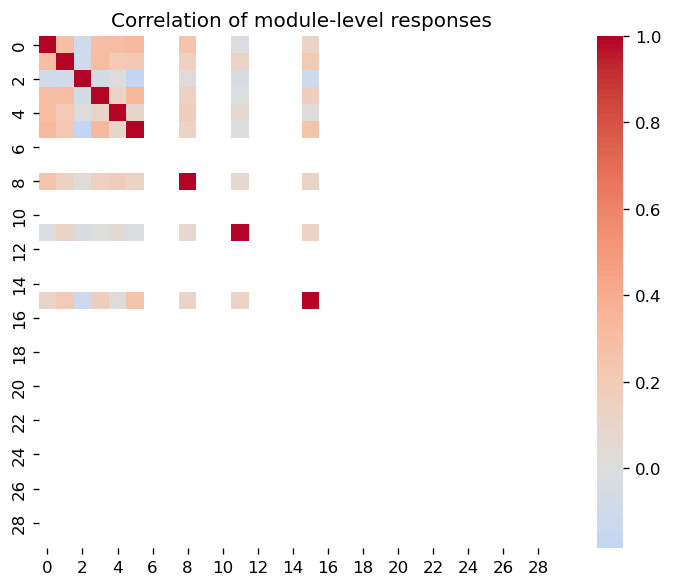

,deletion_module,p_value,n_deletions
5,5,0.100603,155
2,2,0.150075,285
6,8,0.246184,52
8,15,0.270672,5
4,4,0.330704,209
0,0,0.474679,711
1,1,0.606767,481
3,3,0.621921,291
7,11,0.933530,22


In [8]:
# ============================================================
# Cell 8 – Correlation and statistical tests
# ============================================================
import seaborn as sns

# Correlation of module responses
corr_df = module_avg_df.loc[valid_mask, modules].corr(method="spearman")
plt.figure(figsize=(6, 5))
sns.heatmap(corr_df, cmap="coolwarm", center=0)
plt.title("Correlation of module-level responses")
plt.tight_layout()
plt.show()

# Mann–Whitney tests (drop NaNs)
results = []
for m in modules:
    in_m = module_avg_df.loc[(module_avg_df["deletion_module"] == m) & valid_mask, "chaperone_module_delta"].dropna()
    out_m = module_avg_df.loc[(module_avg_df["deletion_module"] != m) & valid_mask, "chaperone_module_delta"].dropna()
    if len(in_m) and len(out_m):
        stat, p = mannwhitneyu(in_m, out_m, alternative="two-sided")
        results.append({"deletion_module": m, "p_value": p, "n_deletions": len(in_m)})
statistics_df = pd.DataFrame(results).sort_values("p_value")
statistics_df.head(10)

### In the current module-level analysis, deletions from individual interactome communities did not show statistically significant global differences in activation of chaperone-rich modules relative to all other deletions. This suggests that perturbation buffering is unlikely to operate as a broad uniform module-wide effect, and is more likely to be gene-specific, pairwise between particular modules, or concentrated in subsets of highly responsive deletions.